In [1]:
pip install scikit-learn-extra

     ---------------------------------------- 0.0/819.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/819.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/819.0 kB ? eta -:--:--
     ---------------------------------------- 0.0/819.0 kB ? eta -:--:--
     ------------ --------------------------- 262.1/819.0 kB ? eta -:--:--
     ------------ --------------------------- 262.1/819.0 kB ? eta -:--:--
     ------------ --------------------------- 262.1/819.0 kB ? eta -:--:--
     ------------ --------------------------- 262.1/819.0 kB ? eta -:--:--
     ------------ --------------------------- 262.1/819.0 kB ? eta -:--:--
     ------------ --------------------------- 262.1/819.0 kB ? eta -:--:--
     ------------ --------------------------- 262.1/819.0 kB ? eta -:--:--
     ------------ --------------------------- 262.1/819.0 kB ? eta -:--:--
     ------------ --------------------------- 262.1/819.0 kB ? eta -:--:--
     ----------------------- ----


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn_extra.cluster import KMedoids

from sklearn.metrics import silhouette_score

In [3]:
data = pd.read_csv("Wholesale customers data.csv")

In [4]:
print(data.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [5]:
print(data.columns)

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [6]:
X = data.iloc[:, 2:]

# Step 7 : Feature Scaling

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [8]:
scores = []

# Step 9 : Apply K-Medoids for Different K Values

In [9]:
for i in range(2, 11):

    kmedoids = KMedoids(
        n_clusters=i,
        random_state=42
    )

    labels = kmedoids.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

# Step 10 : Plot Silhouette Scores

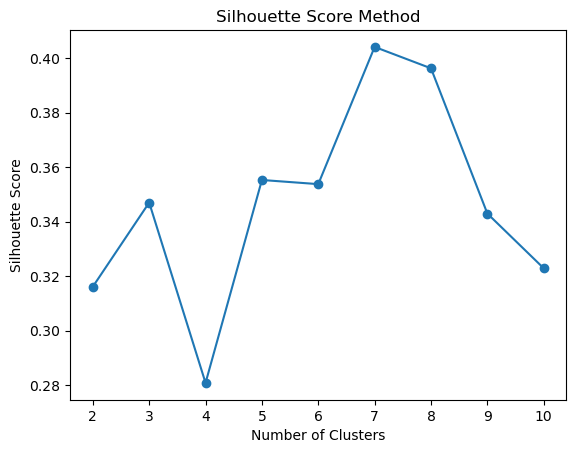

In [10]:
plt.plot(range(2,11), scores, marker='o')
plt.title('Silhouette Score Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

# Step 11 : Apply Final K-Medoids Model

In [12]:
kmedoids = KMedoids(
    n_clusters=3,
    random_state=42)
clusters = kmedoids.fit_predict(X_scaled)

In [13]:
print(data.head())

   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
